# prep.benchmark

The goal of this notebook is to prepare the outputs of the test-8 benchmark run, aimed to test meta-transcriptomic recall and sensitivity using synthetic data. 



In [50]:
import pandas as pd
import taxoniq
import seaborn as sns 
import numpy as np
from scipy.stats import kruskal, dunnett
from miripvir25.statistics import mann_whitney_posthoc
from miripvir25.metrics import assess_taxonomic_classification_metrics
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
sns.set_palette('pastel')


## Building reference

In [51]:
def read_abundance_file(filename, label):
    u = pd.read_csv(filename, sep=';', index_col=0).query('strand == "R1"')
    u['label'] = label
    return u

with open("../results/2025-11-18.test-8/reference/.input") as f:
    reports_input = list(map(lambda x: x.strip(), f.readlines()))

reports = pd.concat([read_abundance_file("../results/2025-11-18.test-8/reference/" + file, file.replace(".abundance.txt", "")) for file in reports_input]).drop(columns=['strand'])
reports['source'] = reports['label'].apply(lambda x: x.split(".")[1])
reports['level'] = reports['label'].apply(lambda x: x.split(".")[2])
reports['repetition'] = reports['label'].apply(lambda x: x.split(".")[3])
reports['label'] = reports['label'].apply(lambda x: ".".join(x.split(".")[:4]))
reports = reports.rename(columns={'taxid': 'ncbi_taxid'})
reports

,ncbi_taxid,count,label,source,level,repetition
index,,,,,,
0,3702,9.000024e-01,test-8.00.090.001,00,090,001
1,357804,3.139540e-02,test-8.00.090.001,00,090,001
2,1388658,3.073780e-02,test-8.00.090.001,00,090,001
3,1287336,1.383860e-02,test-8.00.090.001,00,090,001
4,2902634,6.315000e-03,test-8.00.090.001,00,090,001
...,...,...,...,...,...,...
81,2292973,6.000000e-07,test-8.04.099.005,04,099,005
82,427683,4.000000e-07,test-8.04.099.005,04,099,005
83,1503981,4.000000e-07,test-8.04.099.005,04,099,005


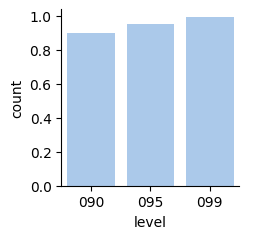

In [52]:
sns.catplot(data=reports.query('ncbi_taxid == 3702'), y='count', x='level', kind='bar', height=2.5)

## Read functions


In [53]:
def fault_tolerant_rank(x):
    try:
        return taxoniq.Taxon(x).rank.name
    except KeyError:
        return pd.NA




def read_motus_output(filename, method, label):
    tmp = pd.read_csv(filename, sep="\t", comment='#', header=None, names=['otu', 'scientific_name', 'taxid', 'count']).dropna(subset=['taxid'])
    tmp['label'] = label
    tmp['method'] = method
    tmp['taxid'] = tmp['taxid'].astype(int)
    tmp = tmp.rename(columns={'taxid': 'ncbi_taxid'})
    return tmp[['label', 'method', 'ncbi_taxid', 'scientific_name']]

def read_sylph_output(filename):
    pass

def read_kraken2_output(filename, method, label):
    kraken2_df = pd.read_csv(filename, sep=',', index_col=None)
    kraken2_df = kraken2_df.rename(columns={'library': 'method', 'taxonid': 'ncbi_taxid'}).drop(columns=['classification-ratio'])
    kraken2_df['rank'] = kraken2_df['ncbi_taxid'].apply(fault_tolerant_rank)
    kraken2_df = kraken2_df.dropna(subset=['rank']).query('rank == "species"').drop(columns=['rank']).copy()
    kraken2_df['method'] = method
    kraken2_df['label'] = label
    kraken2_df = kraken2_df[['label', 'method', 'ncbi_taxid',  'scientific_name', ]]
    return kraken2_df

def read_metaphlan_output(filename, label, method):
    u = pd.read_csv(filename, comment='#', header=None, names=['clade', 'taxid', 'abundance', '_'], sep='\t').dropna(subset=['taxid'])
    u['taxid'] = u['taxid'].astype(str).apply(lambda x: x.split("|")[-1])
    u = u.query('taxid != ""').copy()
    u['taxid'] = u['taxid'].astype(int)
    u['rank'] = u['taxid'].apply(fault_tolerant_rank)
    u = u.dropna(subset=['rank']).query('rank == "species"').copy()
    u = u.rename(columns={'taxid': 'ncbi_taxid'})
    u["label"] = label
    u["method"] = method
    return u[['label', 'method', 'ncbi_taxid']]

## Read files

In [54]:
query_files = pd.read_csv("/Users/brunocuevaszuviria/projects/miripvir25/results/2025-11-18.test-8/query/.input", header=None, names=['filename'])
query_files['source'] = query_files['filename'].apply(lambda x: x.split(".")[1])
query_files['level'] = query_files['filename'].apply(lambda x: x.split(".")[2])
query_files['repetition'] = query_files['filename'].apply(lambda x: x.split(".")[3])
query_files['method'] = query_files['filename'].apply(lambda x: x.split(".")[4])
query_files['label'] = query_files['filename'].apply(lambda x: '.'.join(x.split(".")[:4]))
query_files

,filename,source,level,repetition,method,label
0,test-8.00.090.001.kraken2-h.csv,00,090,001,kraken2-h,test-8.00.090.001
1,test-8.00.090.001.kraken2-l.csv,00,090,001,kraken2-l,test-8.00.090.001
2,test-8.00.090.001.kraken2-m.csv,00,090,001,kraken2-m,test-8.00.090.001
3,test-8.00.090.001.metaphlan.csv,00,090,001,metaphlan,test-8.00.090.001
4,test-8.00.090.001.motus-g1.csv,00,090,001,motus-g1,test-8.00.090.001
...,...,...,...,...,...,...
520,test-8.04.099.005.kraken2-m.csv,04,099,005,kraken2-m,test-8.04.099.005
521,test-8.04.099.005.metaphlan.csv,04,099,005,metaphlan,test-8.04.099.005
522,test-8.04.099.005.motus-g1.csv,04,099,005,motus-g1,test-8.04.099.005
523,test-8.04.099.005.motus-g2.csv,04,099,005,motus-g2,test-8.04.099.005


I wrapped all the reads within a function to keep the variable space clean. 

In [55]:
def read_query_files():
    query_read_lists = []
    for _, row in query_files.iterrows():

        if row.method == 'motus-g1': 
            query_read_lists.append(read_motus_output(
                filename='../results/2025-11-18.test-8/query/' + row.filename,
                method='motus-g1', label=row.label
            ))
        elif row.method == 'motus-g2': 
            query_read_lists.append(read_motus_output(
                filename='../results/2025-11-18.test-8/query/' + row.filename,
                method='motus-g2', label=row.label
            ))
        elif row.method == 'motus-g3': 
            query_read_lists.append(read_motus_output(
                filename='../results/2025-11-18.test-8/query/' + row.filename,
                method='motus-g3', label=row.label
            ))
        elif row.method == 'kraken2-h': 
            query_read_lists.append(read_kraken2_output(
                filename='../results/2025-11-18.test-8/query/' + row.filename,
                method='kraken2-c3', label=row.label
            ))
        elif row.method == 'kraken2-m': 
            query_read_lists.append(read_kraken2_output(
                filename='../results/2025-11-18.test-8/query/' + row.filename,
                method='kraken2-c2', label=row.label
            ))
        elif row.method == 'kraken2-l': 
            query_read_lists.append(read_kraken2_output(
                filename='../results/2025-11-18.test-8/query/' + row.filename,
                method='kraken2-c1', label=row.label
            ))
        elif row.method == 'metaphlan': 
            query_read_lists.append(read_metaphlan_output(
                filename='../results/2025-11-18.test-8/query/' + row.filename,
                method='metaphlan', label=row.label
            ))
    return query_read_lists
query_hits = pd.concat(read_query_files())
query_hits

,label,method,ncbi_taxid,scientific_name
0,test-8.00.090.001,kraken2-c3,3702,Arabidopsis thaliana
19,test-8.00.090.001,kraken2-c3,3077335,Mesorhizobium sp. ISC25
21,test-8.00.090.001,kraken2-c3,317577,Deinococcus ficus
27,test-8.00.090.001,kraken2-c3,1851544,Orrella dioscoreae
30,test-8.00.090.001,kraken2-c3,210,Helicobacter pylori
...,...,...,...,...
2,test-8.04.099.005,motus-g2,146786,Thermosynechococcus elongatus
3,test-8.04.099.005,motus-g2,1579378,archaeon GW2011_AR20
4,test-8.04.099.005,motus-g2,1736215,Sphingomonas sp. Leaf33
0,test-8.04.099.005,motus-g3,1579378,archaeon GW2011_AR20


## Evaluation

We use the function implemented in miripvir25.metrics to evaluate the performance of each model in each case. 

In [56]:
# reference = reports.groupby(by=['ncbi_taxid', 'label'])['ncbi_taxid'].apply(list).reset_index()

reference = reports.query('ncbi_taxid != 3702').groupby('label')['ncbi_taxid'].apply(lambda x: list([item] for item in x)).reset_index()
evaluation = query_hits.groupby(['method', 'label'])['ncbi_taxid'].apply(list).reset_index()
evaluation = pd.merge(evaluation, reference, on='label', how='right', suffixes=['_q', '_r'])

evaluation['report'] = evaluation.apply(lambda x: assess_taxonomic_classification_metrics(x.ncbi_taxid_r, x.ncbi_taxid_q, ""), axis=1)
evaluation['TP'] = evaluation['report'].apply(lambda x: x['TP'])
evaluation['FN'] = evaluation['report'].apply(lambda x: x['FN'])
evaluation['FP'] = evaluation['report'].apply(lambda x: x['FP'])
evaluation['Q'] = evaluation['report'].apply(lambda x: x['Q'])
evaluation['P'] = evaluation['report'].apply(lambda x: x['P'])
evaluation['recall'] = evaluation['report'].apply(lambda x: x['TP'] / (x['TP'] + x['FN']))
evaluation['precision'] = evaluation['report'].apply(lambda x: x['TP'] / (x['TP'] + x['FP']))
evaluation['F1'] = evaluation['report'].apply(lambda x: 2 * x['TP'] / (2 * x['TP'] + x['FP'] + x['FN']))
evaluation['source'] = evaluation['label'].apply(lambda x: x.split(".")[1])
evaluation['level'] = evaluation['label'].apply(lambda x: x.split(".")[2])
evaluation['repetition'] = evaluation['label'].apply(lambda x: x.split(".")[3])
evaluation['label'] = evaluation['label'].apply(lambda x: ".".join(x.split(".")[:4]))
evaluation['family'] = evaluation['method'].apply(lambda x: x.split("-")[0])
evaluation


,method,label,ncbi_taxid_q,ncbi_taxid_r,report,TP,FN,FP,Q,P,recall,precision,F1,source,level,repetition,family
0,kraken2-c1,test-8.00.090.001,"[3702, 3077335, 2899133, 1280, 317577, 1851544...","[[357804], [1388658], [1287336], [2902634], [2...","{'method': '', 'TP': 24, 'FP': 143, 'FN': 55, ...",24,55,143,79,167,0.303797,0.143713,0.195122,00,090,001,kraken2
1,kraken2-c2,test-8.00.090.001,"[3702, 3077335, 2899133, 317577, 1851544, 210,...","[[357804], [1388658], [1287336], [2902634], [2...","{'method': '', 'TP': 22, 'FP': 35, 'FN': 57, '...",22,57,35,79,57,0.278481,0.385965,0.323529,00,090,001,kraken2
2,kraken2-c3,test-8.00.090.001,"[3702, 3077335, 317577, 1851544, 210, 2899133,...","[[357804], [1388658], [1287336], [2902634], [2...","{'method': '', 'TP': 15, 'FP': 15, 'FN': 64, '...",15,64,15,79,30,0.189873,0.500000,0.275229,00,090,001,kraken2
3,metaphlan,test-8.00.090.001,"[1280, 357794, 713054, 1078905, 210, 28901, 31...","[[357804], [1388658], [1287336], [2902634], [2...","{'method': '', 'TP': 5, 'FP': 8, 'FN': 74, 'P'...",5,74,8,79,13,0.063291,0.384615,0.108696,00,090,001,metaphlan
4,motus-g1,test-8.00.090.001,"[28901, 470, 1280, 81475, 1851544, 1287336, 13...","[[357804], [1388658], [1287336], [2902634], [2...","{'method': '', 'TP': 18, 'FP': 15, 'FN': 61, '...",18,61,15,79,33,0.227848,0.545455,0.321429,00,090,001,motus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,kraken2-c3,test-8.04.099.005,"[3702, 3049047, 582, 61624, 224719, 1879050, 9...","[[1805248], [2955316], [1437360], [1579378], [...","{'method': '', 'TP': 4, 'FP': 10, 'FN': 81, 'P...",4,81,10,85,14,0.047059,0.285714,0.080808,04,099,005,kraken2
521,metaphlan,test-8.04.099.005,[2955316],"[[1805248], [2955316], [1437360], [1579378], [...","{'method': '', 'TP': 1, 'FP': 0, 'FN': 84, 'P'...",1,84,0,85,1,0.011765,1.000000,0.023256,04,099,005,metaphlan
522,motus-g1,test-8.04.099.005,"[1280, 92645, 864069, 59620, 1348249, 146786, ...","[[1805248], [2955316], [1437360], [1579378], [...","{'method': '', 'TP': 7, 'FP': 6, 'FN': 78, 'P'...",7,78,6,85,13,0.082353,0.538462,0.142857,04,099,005,motus
523,motus-g2,test-8.04.099.005,"[146786, 1579378, 1736215]","[[1805248], [2955316], [1437360], [1579378], [...","{'method': '', 'TP': 2, 'FP': 1, 'FN': 83, 'P'...",2,83,1,85,3,0.023529,0.666667,0.045455,04,099,005,motus


### F1 scores

We can consider the F1-score as a metric providing a balanced view of both recall and sensitvity.

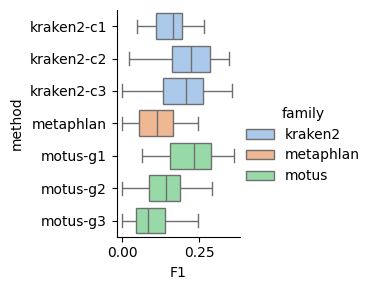

In [57]:
sns.catplot(y='method', x='F1', data=evaluation, kind='box', height=3.0, aspect=1.0, whis=1000, hue='family')

In [58]:
kt = kruskal(*evaluation.groupby(['method'])['F1'].apply(list).values)
print("Kruskal Wallis, F1 by method")
print(" p -value  {:12.8f}".format(kt.pvalue))
print(" H         {:12.4f}".format(kt.statistic))

Kruskal Wallis, F1 by method
 p -value    0.00000000
 H             161.7780


<Axes: xlabel='group_2', ylabel='group_1'>

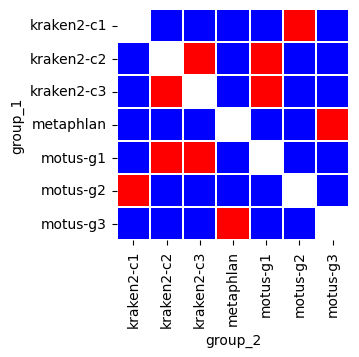

In [59]:
ph = mann_whitney_posthoc(evaluation, 'method', 'F1')
fig, ax = plt.subplots(1)
fig.set_size_inches(3, 3)
sns.heatmap(
    ph.pivot(index='group_1', columns='group_2', values='p-val').clip(0.0499, 0.0501),
    cmap='bwr', cbar=False, linewidths=0.05
)

Now we look at the same data by host abundance level

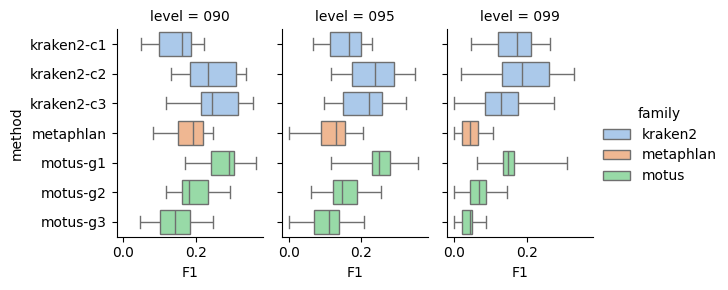

In [60]:
sns.catplot(y='method', x='F1', data=evaluation, col='level', kind='box', height=3.0, aspect=0.7, whis=1000, hue='family')

In [79]:
def compute_f1_bylevels():
    out = []
    kt = kruskal(*evaluation.query('level == "090"').groupby(['method'])['F1'].apply(list).values)
    out.append({'level': '090', 'H': kt.statistic, 'p-value': kt.pvalue})
    kt = kruskal(*evaluation.query('level == "095"').groupby(['method'])['F1'].apply(list).values)
    out.append({'level': '095', 'H': kt.statistic, 'p-value': kt.pvalue})
    kt = kruskal(*evaluation.query('level == "099"').groupby(['method'])['F1'].apply(list).values)
    out.append({'level': '099', 'H': kt.statistic, 'p-value': kt.pvalue})
    return  pd.DataFrame.from_records(out)
compute_f1_bylevels().round(4).T

,0,1,2
level,090,095,099
H,75.9303,75.8401,106.0077
p-value,0.0,0.0,0.0


Text(397.67973856209153, 0.5, '')

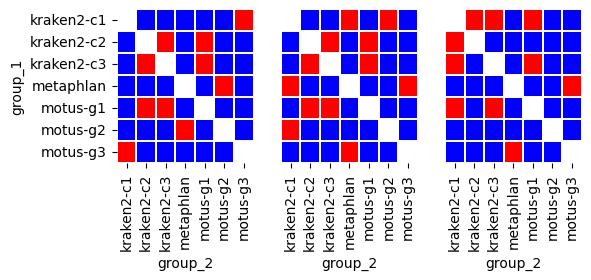

In [78]:

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(6, 2)
ph = mann_whitney_posthoc(evaluation.query('level == "090"'), 'method', 'F1')
sns.heatmap(
    ph.pivot(index='group_1', columns='group_2', values='p-val').clip(0.0499, 0.0501),
    cmap='bwr', cbar=False, linewidths=0.05, ax=ax[0]
)
ph = mann_whitney_posthoc(evaluation.query('level == "095"'), 'method', 'F1')
sns.heatmap(
    ph.pivot(index='group_1', columns='group_2', values='p-val').clip(0.0499, 0.0501),
    cmap='bwr', cbar=False, linewidths=0.05, ax=ax[1], yticklabels=[]
)
ph = mann_whitney_posthoc(evaluation.query('level == "099"'), 'method', 'F1')
sns.heatmap(
    ph.pivot(index='group_1', columns='group_2', values='p-val').clip(0.0499, 0.0501),
    cmap='bwr', cbar=False, linewidths=0.05, ax=ax[2], yticklabels=[]
)
ax[1].set_ylabel("")
ax[2].set_ylabel("")

In [71]:
def run_mutiple_dunnet_tests(data, methods):
    M = []
    for control in methods:
        
        dn = dunnett(
            *[data.query('method == "{:s}"'.format(method))['F1'] for method in methods if method != control],
            control=data.query('method == "{:s}"'.format(control))['F1'],
            alternative='less'
        )
        other_methods = [method for method in methods if method != control]
        for method, pvalue in zip(other_methods, dn.pvalue):
            M.append(
                {
                    "control": control,
                    "method": method,
                    "p-val":pvalue * len(methods),
                }
            )

    M = pd.DataFrame.from_records(M).pivot(index='control', columns='method', values='p-val')
    M = M.T 
    M = M.T 
    return M

In [72]:
methods = evaluation['method'].unique().tolist()
M90 = run_mutiple_dunnet_tests(evaluation.query('level == "090"'), methods=methods)
M95 = run_mutiple_dunnet_tests(evaluation.query('level == "095"'), methods=methods)
M99 = run_mutiple_dunnet_tests(evaluation.query('level == "099"'), methods=methods)

Text(397.67973856209153, 0.5, '')

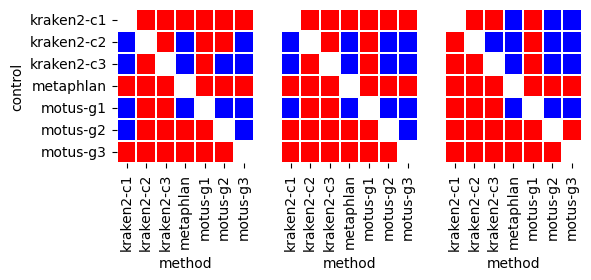

In [73]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(6, 2.0)
sns.heatmap(
    M90.clip(lower=0.04999, upper=0.05001),
    cmap='bwr', linecolor='white', linewidths=0.05, 
    mask=np.eye(len(methods), len(methods), dtype=bool), cbar=False,
    ax=ax[0]
)
sns.heatmap(
    M95.clip(lower=0.04999, upper=0.05001), 
    cmap='bwr', linecolor='white', linewidths=0.05, 
    mask=np.eye(len(methods), len(methods), dtype=bool),cbar=False,
    ax=ax[1], yticklabels=[]
)
sns.heatmap(
    M99.clip(lower=0.04999, upper=0.05001),
    cmap='bwr', linecolor='white', linewidths=0.05, 
    mask=np.eye(len(methods), len(methods), dtype=bool),cbar=False,
    ax=ax[2], yticklabels=[]
)
ax[1].set_ylabel("")
ax[2].set_ylabel("")

## Recall and sensitivity

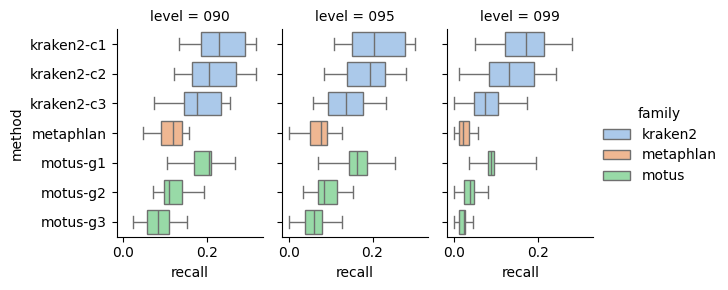

In [66]:
sns.catplot(y='method', x='recall', data=evaluation, col='level', kind='box', height=3.0, aspect=0.7, whis=1000, hue='family')

In [75]:
kt = kruskal(*evaluation.groupby(['method'])['recall'].apply(list).values)
print("Kruskal Wallis, recall by method")
print(" p -value  {:12.8f}".format(kt.pvalue))
print(" H         {:12.4f}".format(kt.statistic))

Kruskal Wallis, recall by method
 p -value    0.00000000
 H             253.9201


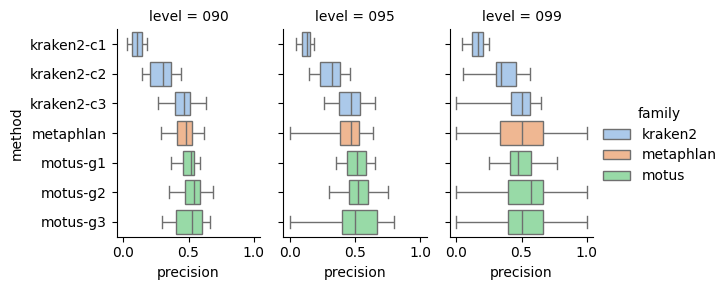

In [67]:
sns.catplot(y='method', x='precision', data=evaluation, col='level', kind='box', height=3.0, aspect=0.7, whis=1000, hue='family')

In [77]:
kt = kruskal(*evaluation.groupby(['method'])['precision'].apply(list).values)
print("Kruskal Wallis, precision by method")
print(" p -value  {:12.8f}".format(kt.pvalue))
print(" H         {:12.4f}".format(kt.statistic))

Kruskal Wallis, precision by method
 p -value    0.00000000
 H             250.9295
